# events/xselect

迁移自 / Migrated from `test/test_xselect.ipynb`.

状态 / Status: **data_required**. 需要事件、源和背景文件以及 XSELECT / Requires event/source/background files and XSELECT

历史输出保留，不代表迁移后重新验证；原报错数量 / Preserved historical errors: 0.
Historical outputs are retained and are not evidence of a new successful run.

输入路径在下一单元集中配置；原始数据留在原位置。
Input roots are configured below; original data remain in place.


In [ ]:
# 从仓库定位输入，允许通过环境变量覆盖；不移动原始数据。
# Locate repository inputs with environment overrides; original data stay in place.
from pathlib import Path
from datetime import datetime, timezone
import os
_anchor = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
REPO_ROOT = next((p for p in (_anchor, *_anchor.parents)
                  if (p/'packages/jinwu').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('请从 JinWu 仓库内运行 / Run from within the JinWu checkout')
RESEARCH_ROOT = Path(os.environ.get('JINWU_EXAMPLE_RESEARCH_ROOT', REPO_ROOT.parent))
TEST_DATA_ROOT = Path(os.environ.get('JINWU_EXAMPLE_TEST_ROOT', REPO_ROOT/'test'))
DOWNLOAD_ROOT = Path(os.environ.get('JINWU_EXAMPLE_DOWNLOAD_ROOT', Path.home()/'下载'))
# 图件写入独立运行目录，不覆盖研究目录中的历史图。
# Write figures into a unique run directory, preserving historical research plots.
OUTPUT_DIR = Path(os.environ.get('JINWU_EXAMPLE_OUTPUT_ROOT', REPO_ROOT/'examples/_outputs')) / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)


In [1]:
from pathlib import Path
evtpath = Path(str(RESEARCH_ROOT / 'EP250315a/ep13600005120wxtCMOS2l23v3_20251016_225305/ep13600005120wxt2po_cl.evt'))

In [2]:
from jinwu.core import readfits
evt = readfits(str(RESEARCH_ROOT / 'EP250315a/ep13600005120wxtCMOS2l23v3_20251016_225305/ep13600005120wxt2po_cl.evt'))

In [4]:
lc= evt.extract_curve(binsize=1)

In [5]:
lc.time

array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 3.6955e+04, 3.6956e+04,
       3.6957e+04], shape=(36958,))

<Axes: title={'center': 'ep13600005120wxt2po_cl.evt'}, xlabel='Time since 2024-03-15T18:27:18.200 (UTC) (s)  [WXT | Δt=1.000 s]', ylabel='Counts'>

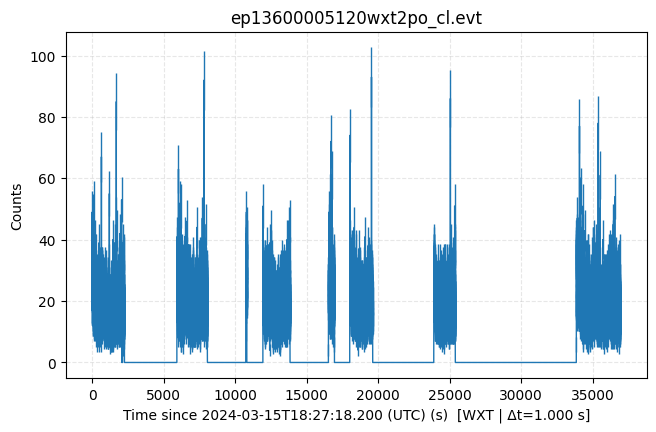

In [6]:
lc.plot()

In [5]:
lc.value

array([22., 36., 17., ..., 15., 14., 13.], shape=(36958,))

In [6]:
lc.timezero

132690438.2

In [7]:
lc.telescop

'EP'

In [8]:
lc.timezero_obj

<Time object: scale='utc' format='ep' value=132690438.2>

<Axes: title={'center': 'ep13600005120wxt2po_cl.evt'}, xlabel='Time since 2024-03-15T18:27:18.200 (UTC) (s)  [WXT | Δt=1.000 s]', ylabel='Counts'>

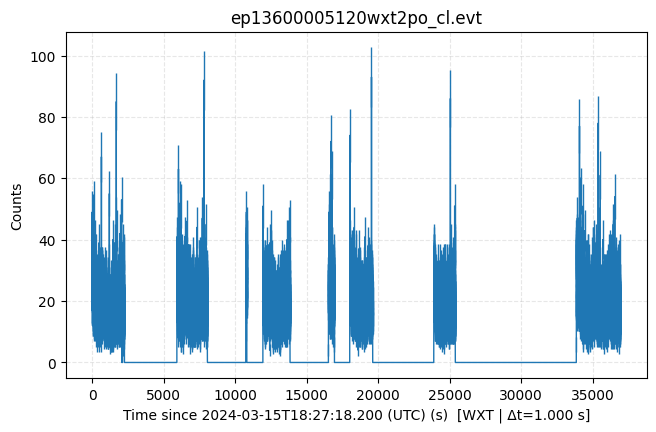

In [9]:
lc.plot()

In [10]:
evt.clear_all()

EventData(path=PosixPath('/home/xinxiang/research/EP250315a/ep13600005120wxtCMOS2l23v3_20251016_225305/ep13600005120wxt2po_cl.evt'), header={'XTENSION': 'BINTABLE', 'BITPIX': 8, 'NAXIS': 2, 'NAXIS1': 33, 'NAXIS2': 244685, 'PCOUNT': 0, 'GCOUNT': 1, 'TFIELDS': 12, 'TTYPE1': 'TIME', 'TFORM1': '1D', 'TUNIT1': 's', 'TTYPE2': 'RAWX', 'TFORM2': '1I', 'TUNIT2': 'pixel', 'TTYPE3': 'RAWY', 'TFORM3': '1I', 'TUNIT3': 'pixel', 'TTYPE4': 'Amp', 'TFORM4': '1B', 'TTYPE5': 'PHA', 'TFORM5': '1J', 'TUNIT5': 'chan', 'TTYPE6': 'STATUS', 'TFORM6': '16X', 'EXTNAME': 'EVENTS', 'TLMIN2': 1, 'TLMAX2': 4096, 'TCTYP2': 'RAWX', 'TCRVL2': 2048.5, 'TCDLT2': 1, 'TCRPX2': 2048.5, 'TLMIN3': 1, 'TLMAX3': 4096, 'TCTYP3': 'RAWY', 'TCRVL3': 2048.5, 'TCDLT3': 1, 'TCRPX3': 2048.5, 'MTYPE1': 'RAW', 'MFORM1': 'RAWX, RAWY', 'TLMIN5': 0, 'TLMAX5': 4095, 'HDUCLASS': 'OGIP', 'HDUCLAS1': 'EVENTS', 'TIMESYS': 'TT', 'MJDREFI': 58849, 'MJDREFF': 0.00080074074, 'TIMEREF': 'LOCAL', 'TASSIGN': 'SATELLITE', 'TIMEUNIT': 's', 'TIERRELA': 1e

In [11]:
lc = evt.extract_curve(binsize=1)

In [12]:
lc.time

array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 3.6955e+04, 3.6956e+04,
       3.6957e+04], shape=(36958,))

<Axes: title={'center': 'ep13600005120wxt2po_cl.evt'}, xlabel='Time since 2024-03-15T18:27:18.200 (UTC) (s)  [WXT | Δt=1.000 s]', ylabel='Counts'>

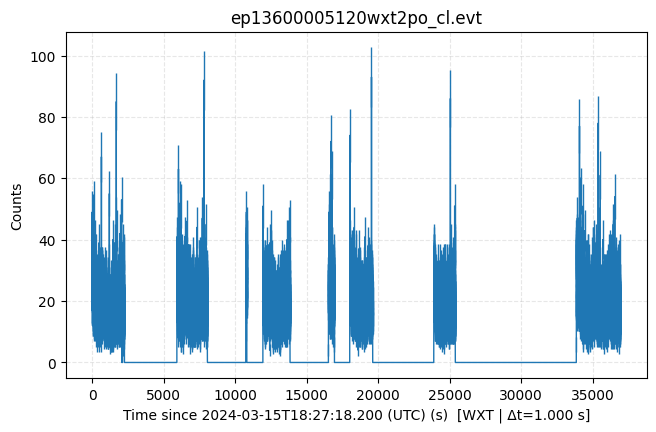

In [13]:
lc.plot()

In [14]:
from pathlib import Path
out_lc = Path(str(OUTPUT_DIR / 'xselect_lc.fits'))
evt.filter_time(tmin=0, tmax=1000)  # 再次加一个时间过滤
lc = evt.extract_curve(binsize=1.0)
saved_path = evt.save(out_lc, kind="lc", binsize=1.0, overwrite=True)
saved_path

PosixPath('/home/xinxiang/research/jinwu/test/xselect_lc.fits')

In [15]:
bkglc = readfits(str(RESEARCH_ROOT / 'EP250315a/ep13600005120wxtCMOS2l23v3_20251016_225305/ep13600005120wxt2s1bk.lc'))
srclc = readfits(str(RESEARCH_ROOT / 'EP250315a/ep13600005120wxtCMOS2l23v3_20251016_225305/ep13600005120wxt2s1.lc'))

In [16]:
srclc.value

array([0., 0., 0., ..., 0., 0., 0.], shape=(12941,))

In [17]:
bkglc.value

array([0., 0., 0., ..., 0., 0., 0.], shape=(12941,))

In [18]:
lc = srclc - bkglc

In [19]:
lc.timezero

132690438.657

In [20]:
lc.timezero_obj.utc.isot

'2024-03-15T18:27:18.657'

<Axes: title={'center': 'EP250315a (ep13600005120wxt2s1.lc)'}, xlabel='Time since 2024-03-15T20:06:08.657 (UTC) (s)  [WXT | Δt=20.000 s]', ylabel='Rate (counts s$^{-1}$)'>

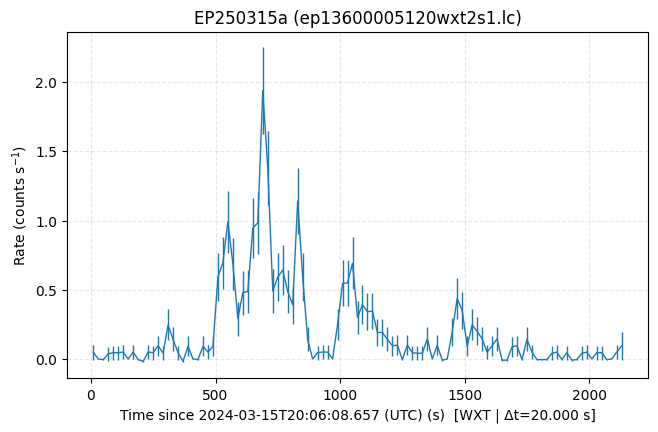

In [21]:
lc.slice(5000, 10000).rebin(binsize=20).plot(srcname = 'EP250315a')

In [22]:
lcnew = lc.slice(5000, 10000)

In [23]:
lcnew.timezero_obj

<Time object: scale='utc' format='ep' value=132696368.657>

<Axes: title={'center': 'EP250315a (ep13600005120wxt2s1.lc)'}, xlabel='Time since 2024-03-15T20:06:08.657 (UTC) (s)  [WXT | Δt=20.000 s]', ylabel='Rate (counts s$^{-1}$)'>

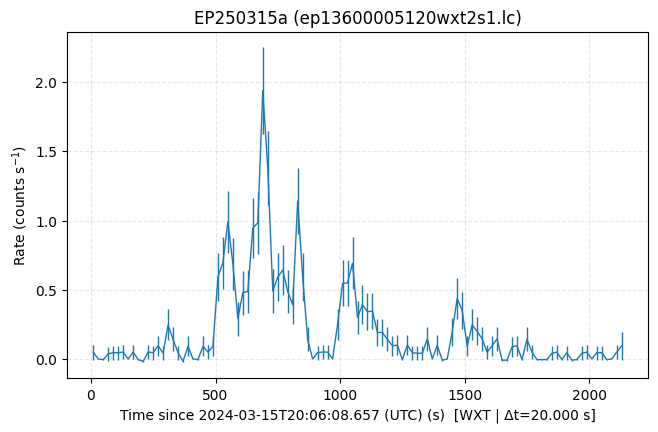

In [24]:
lc.slice(5000,10000).rebin(binsize=20).plot(srcname = 'EP250315a')

In [25]:
lc= readfits(str(RESEARCH_ROOT / 'EP250315a/ep13600005120wxtCMOS2l23v3_20251016_225305/ep13600005120wxt2s1.lc'))


In [26]:
lc.timezero

132690438.657

In [27]:
lc.tstart

132690438.657

In [28]:
lc.dt

1.0

In [29]:
from jinwu.core.time import TimeDelta

In [30]:
TimeDelta(1, format='sec')

<TimeDelta object: scale='None' format='sec' value=1.0>